In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import torch
import torch_geometric as pyg
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt

from bipartite_gnn.graph_visualizatons import visualize_graph, visualize_embeddings
from baseline_evals.feature_selection import variance_filtering, class_variational_selection
from bipartite_gnn.preprocessing import mrmr_selection
from baseline_evals.knn_eval import knn_eval
from baseline_evals.svm_eval import svm_eval
from baseline_evals.xgboost_eval import xgboost_eval
from baseline_evals.mlp_eval import mlp_eval
from gnn_experiments.mogonet_eval import mogonet_eval

In [2]:
mrna = pl.read_csv('MDS_data_preprocessed/mrna.csv')
mirna = pl.read_csv('MDS_data_preprocessed/mirna.csv')
circrna = pl.read_csv('MDS_data_preprocessed/circrna.csv')
te_counts = pl.read_csv('MDS_data_preprocessed/te_counts.csv')
pirna = pl.read_csv('MDS_data_preprocessed/pirna.csv')

annot = pl.read_csv('MDS_data_preprocessed/annotations.csv')

In [3]:
mrna.shape, mirna.shape, circrna.shape, te_counts.shape, pirna.shape, annot.shape

((19873, 75), (1879, 75), (69, 75), (687, 75), (219, 67), (74, 5))

In [3]:
sample_names = annot['SAMPLE_NAME'].to_list()
sample_names = [name.split('_')[0] for name in sample_names]

assert sample_names == mrna.columns[1:]  == mirna.columns[1:] == circrna.columns[1:] == te_counts.columns[1:]

In [5]:
pirna_sample_names = pirna.columns[1:]

all_common_sample_names = list(set(pirna_sample_names).intersection(set(sample_names)))

In [6]:
mrna_s = mrna.select(['GENE_NAME'] + all_common_sample_names)
mirna_s = mirna.select(['GENE_NAME'] + all_common_sample_names)
circrna_s = circrna.select(['circRNA_ID'] + all_common_sample_names)
te_counts_s = te_counts.select(['TE'] + all_common_sample_names)

In [7]:
annot_s = annot.filter(pl.col('sample_ids').is_in(all_common_sample_names))

In [56]:
import os

In [59]:
for mirna_file in os.listdir('BRCA_PROCESSED_DATA/mrmr_selected/mirna'):
    print(mirna_file)
    # mirna = pl.read_csv(f'MDS_data_preprocessed/mirna/{mirna_file}')
    # mirna_s = mirna.select(['GENE_NAME'] + all_common_sample_names)
    # mirna_s.write_csv(f'MDS_data_preprocessed/mirna/{mirna_file}')

mirna_fold_0.csv
mirna_fold_1.csv
mirna_fold_4.csv
mirna_fold_3.csv
mirna_fold_2.csv


In [10]:
mrna

GENE_NAME,V1884,N58,V630,N60,V1297,NV1428,N82,V940,V2092,V624,V777,V553,V1441,V1921,V538,V1857,V456,NV912,V2089,V1823,V2241,N54,V655,V2110,V839,V125,N83,V637,V712,NV911,V2133,V1742,V1591,V108,V1874,V221,V148,N70,N87,V574,V359,V1337,V883,V1592,V1422,V1708,V1505,V18,V1788,V1776,N84,V1800,V716,N86,V888,V1321,V1279,V1528,V344,N85,V1699,V1456,V1394,V714,V67,V1090,V1860,V406,V1834,V1048,V806,V513,V1565,V1920
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""RILPL1""",187,235,538,244,256,131,89,364,362,164,167,426,128,200,128,276,314,114,120,570,376,407,131,315,139,172,232,44,65,133,93,698,226,60,114,170,203,266,279,352,715,195,273,210,106,139,223,233,184,62,198,464,355,134,474,393,146,153,120,246,345,239,110,92,432,207,373,180,301,404,458,263,384,649
"""RAB4B""",1296,951,1261,856,613,849,749,813,937,1989,882,2094,527,914,948,434,920,454,1798,792,1165,951,685,812,907,710,865,460,786,555,304,1420,1177,1080,2095,636,1026,905,681,1350,1514,1348,887,753,765,1195,1317,860,1033,860,1441,1683,1304,851,1130,1526,1111,1183,1137,682,2000,1259,1390,1370,1374,812,1238,1024,1072,764,801,989,1682,943
"""TIGAR""",1229,184,609,691,173,325,393,227,424,817,243,998,686,332,219,314,366,329,511,567,511,580,342,218,1073,296,356,80,217,240,142,994,488,301,799,304,485,258,277,376,475,504,328,568,133,452,322,453,197,210,288,582,1098,275,362,343,404,309,590,482,793,606,878,630,408,240,340,564,371,404,499,400,508,204
"""DNAH3""",5,0,12,16,12,3,30,2,92,0,10,20,6,0,2,190,3,10,12,6,7,18,134,17,109,29,4,0,9,3,266,5,3,3,6,0,195,8,9,43,4,0,0,0,2,3,8,2,3,4,10,7,23,18,19,97,0,0,8,0,33,0,4,80,6,0,7,3,115,0,3,0,11,22
"""RP11-432M8.3""",2,1,1,0,3,0,2,1,7,0,0,2,1,0,0,17,0,1,0,0,1,0,7,2,1,3,2,0,1,0,8,5,1,1,0,0,0,0,1,0,6,0,4,0,0,0,1,0,0,1,1,0,0,1,2,2,0,2,0,2,3,0,0,0,1,0,3,1,11,0,0,0,0,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CYP4F2""",291,182,157,25,43,114,178,171,14,458,7,8,621,116,177,66,11,57,22,117,119,152,58,474,226,81,120,191,481,26,58,178,50,129,509,59,255,144,203,96,38,32,152,1116,324,370,115,275,18,169,105,57,138,257,84,139,381,30,248,76,62,138,0,237,213,487,189,8,23,0,11,127,281,225
"""TENM1""",131,32,16,11,46,19,20,32,78,4,35,203,48,23,18,250,38,3,31,3,15,22,777,126,57,31,32,6,18,30,108,170,29,173,81,138,90,42,33,39,231,2876,23,7,26,50,23,0,16,42,26,247,58,75,36,93,25,17,232,25,14,7,28,54,11,5,12,107,237,11,19,7,49,34
"""BATF3""",117,67,351,134,70,64,23,84,109,140,262,184,166,33,67,111,52,72,104,125,119,127,76,92,106,124,216,25,181,17,98,131,103,86,259,315,131,147,58,182,223,115,137,48,100,109,150,200,46,54,82,226,343,51,131,50,76,73,37,90,100,128,34,168,210,178,79,60,117,83,472,74,227,39


In [8]:
y_d = annot_s['1 disease'].to_numpy()
y_r = annot_s['2 risk'].to_numpy()
y_m = annot_s['3 mutations (SF3B1only_wt)'].to_numpy()

np.unique(y_d, return_counts=True), np.unique(y_r, return_counts=True), np.unique(y_m, return_counts=True)

((array([1, 2]), array([ 7, 59])),
 (array([0, 1, 2]), array([15, 27, 24])),
 (array([0, 1, 2]), array([41, 13, 12])))

In [9]:
y_d = annot['1 disease'].to_numpy()
y_r = annot['2 risk'].to_numpy()
y_m = annot['3 mutations (SF3B1only_wt)'].to_numpy()

np.unique(y_d, return_counts=True), np.unique(y_r, return_counts=True), np.unique(y_m, return_counts=True)

((array([1, 2]), array([13, 61])),
 (array([0, 1, 2]), array([21, 29, 24])),
 (array([0, 1, 2]), array([48, 14, 12])))

In [10]:
labels = [(y_d, 'disease'), (y_r, 'risk'), (y_m, 'mutation')]

In [54]:
skf = StratifiedKFold(n_splits=5)

omic='pirna'

for y, task in labels:
    for i, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):

        # print(train_idx.shape, test_idx.shape)
        # print(train_idx, test_idx)
        # print(np.unique(y[train_idx], return_counts=True))
        # print(np.unique(y[test_idx], return_counts=True))

        mrna_selected = mrmr_selection(
            X_df=pirna,
            y=y,
            train_mask=train_idx,
            n_features=200,
            n_preselected_features=None,
            feature_col_name="piRNA",
        )

        mrna_selected.write_csv(f"MDS_data_preprocessed/mrmr_selected/{task}/{omic}/{omic}_fold_{i}.csv")

100%|██████████| 200/200 [00:02<00:00, 71.30it/s] 


In [25]:
# prepare pirnas too
# pirna = pl.read_excel("MDS_data/piRNA_counts.xlsx")

# pirna_samples = pirna.columns[1:]

# pirna_samples = [s.split("_")[0] for s in pirna_samples]

# common_samples_w_pirna = list(set(pirna_samples).intersection(set(sample_names)))

# annot_pi = annot.filter(pl.col("sample_ids").is_in(common_samples_w_pirna))

# pirna.columns = ['piRNA'] + pirna_samples
# pirna = pirna.select(['piRNA'] + common_samples_w_pirna)
# pirna_X = pirna.to_numpy()[:, 1:]
# pirna_zeros_mask = pirna_X.sum(axis=1) < 300
# pirna_zeros_idx = np.where(pirna_zeros_mask == False)[0]
# pirna_names = pirna['piRNA'].to_list()
# pirna_names = [name.split('/')[0] for name in pirna_names]
# pirna = pirna.with_columns(piRNA=pl.Series(pirna_names))
# pirna[pirna_zeros_idx].write_csv("MDS_data_preprocessed/pirna.csv")

piRNA,V1565_S17-UMIs,N58_S10-UMIs,V1874_S15-UMIs,V777_S8-UMIs,N80_S20-UMIs,V1788_S3-UMIs,N65_S19-UMIs,V2368_S6-UMIs,N81_S21-UMIs,N59_S18-UMIs,V2286_S2-UMIs,V406_S7-UMIs,V100_S12-UMIs,N82_S1-UMIs,V2133_S13-UMIs,V574_S16-UMIs,V2115_S9-UMIs,V1921_S11-UMIs,V714_S4-UMIs,V637_S14-UMIs,V1742_S5-UMIs,V1744_S2-UMIs,V2248_S3-UMIs,V1428_S4-UMIs,V18_S5-UMIs,V1857_S2-UMIs,V839_S13-UMIs,V912_S21-UMIs,V1048_S9-UMIs,V911_S10-UMIs,V940_S13-UMIs,V681_S21-UMIs,V708_S24-UMIs,N60_S12-UMIs,N70_S11-UMIs,V148_S12-UMIs,…,V1441_S29-UMIs,V1699_S1-UMIs,V1297_S1-UMIs,V1321_S15-UMIs,V1505_S30-UMIs,V1249_S18-UMIs,V1456_S8-UMIs,V1426_S26-UMIs,V1394_S27-UMIs,V1592_S15-UMIs,V1528_S14-UMIs,V1591_S22-UMIs,V833_S6-UMIs,V1708_S27-UMIs,V1800_S16-UMIs,V1776_S23-UMIs,V1823_S11-UMIs,V1775_S15-UMIs,V1834_S3-UMIs,V2378_S19-UMIs,V2414_S10-UMIs,V1860_S4-UMIs,V1884_S28-UMIs,V1920_S7-UMIs,V2322_S18-UMIs,V2311_S18-UMIs,V2291_S17-UMIs,V1957_S6-UMIs,V2092_S17-UMIs,V2284_S16-UMIs,V2278_S20-UMIs,V2110_S7-UMIs,V2179_S9-UMIs,V2147_S8-UMIs,V2224_S19-UMIs,V2089_S1-UMIs,V788_S2-UMIs
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""hsa_piR_006779…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_007653…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_009540…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_000302…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""hsa_piR_000390…",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""hsa_piR_020814…",315,274,230,160,333,154,116,192,213,244,83,147,332,275,94,50,239,168,515,14,122,162,188,111,309,573,18,18,50,59,45,98,70,133,203,138,…,177,108,225,170,193,210,79,42,418,327,144,70,209,246,319,128,88,160,214,139,183,87,94,127,212,78,136,187,67,154,203,222,139,273,161,175,43
"""hsa_piR_020815…",316,458,493,422,279,266,140,417,243,395,220,74,361,450,77,120,715,170,210,12,289,688,336,203,604,137,104,193,270,276,265,202,410,132,225,291,…,340,201,157,1068,389,405,177,89,1005,578,329,314,574,551,458,187,117,421,669,646,183,250,170,131,635,248,170,864,126,293,571,231,224,281,574,183,120
"""hsa_piR_020829…",2732,1064,1346,610,1598,894,848,528,1525,1060,810,565,824,1131,380,1242,833,1493,2428,146,901,1991,378,714,3829,766,226,175,544,380,632,547,312,589,472,1735,…,65,1050,383,193,1198,264,610,112,492,475,1173,1241,330,385,292,375,506,325,687,330,1212,777,665,138,1620,357,621,874,573,661,1069,1170,784,749,1192,921,391


In [11]:
y_d = annot['1 disease'].to_numpy()
y_r = annot['2 risk'].to_numpy()
y_m = annot['3 mutations (SF3B1only_wt)'].to_numpy()

np.unique(y_d, return_counts=True), np.unique(y_r, return_counts=True), np.unique(y_m, return_counts=True)

((array([1, 2]), array([13, 61])),
 (array([0, 1, 2]), array([21, 29, 24])),
 (array([0, 1, 2]), array([48, 14, 12])))

In [12]:
mrna_names = mrna.columns[1:]
mirna_names = mirna.columns[1:]
circrna_names = circrna.columns[1:]
te_names = te_counts.columns[1:]

y_d = annot['1 disease'].to_numpy()
y_r = annot['2 risk'].to_numpy()
y_m = annot['3 mutations (SF3B1only_wt)'].to_numpy()

y = y_d

annotated_samples_mask = y != 0

y = y - 1  # move to 0-indexing

In [29]:
# mrna_genes = mrna["GENE_NAME"]

GENE_NAME,V1884,N58,V630,N60,V1297,NV1428,N82,V940,V2092,V624,V777,V553,V1441,V1921,V538,V1857,V456,NV912,V2089,V1823,V2241,N54,V655,V2110,V839,V125,N83,V637,V712,NV911,V2133,V1742,V1591,V108,V1874,V221,V148,N70,N87,V574,V359,V1337,V883,V1592,V1422,V1708,V1505,V18,V1788,V1776,N84,V1800,V716,N86,V888,V1321,V1279,V1528,V344,N85,V1699,V1456,V1394,V714,V67,V1090,V1860,V406,V1834,V1048,V806,V513,V1565,V1920
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""RILPL1""",187,235,538,244,256,131,89,364,362,164,167,426,128,200,128,276,314,114,120,570,376,407,131,315,139,172,232,44,65,133,93,698,226,60,114,170,203,266,279,352,715,195,273,210,106,139,223,233,184,62,198,464,355,134,474,393,146,153,120,246,345,239,110,92,432,207,373,180,301,404,458,263,384,649
"""RAB4B""",1296,951,1261,856,613,849,749,813,937,1989,882,2094,527,914,948,434,920,454,1798,792,1165,951,685,812,907,710,865,460,786,555,304,1420,1177,1080,2095,636,1026,905,681,1350,1514,1348,887,753,765,1195,1317,860,1033,860,1441,1683,1304,851,1130,1526,1111,1183,1137,682,2000,1259,1390,1370,1374,812,1238,1024,1072,764,801,989,1682,943
"""TIGAR""",1229,184,609,691,173,325,393,227,424,817,243,998,686,332,219,314,366,329,511,567,511,580,342,218,1073,296,356,80,217,240,142,994,488,301,799,304,485,258,277,376,475,504,328,568,133,452,322,453,197,210,288,582,1098,275,362,343,404,309,590,482,793,606,878,630,408,240,340,564,371,404,499,400,508,204
"""DNAH3""",5,0,12,16,12,3,30,2,92,0,10,20,6,0,2,190,3,10,12,6,7,18,134,17,109,29,4,0,9,3,266,5,3,3,6,0,195,8,9,43,4,0,0,0,2,3,8,2,3,4,10,7,23,18,19,97,0,0,8,0,33,0,4,80,6,0,7,3,115,0,3,0,11,22
"""RP11-432M8.3""",2,1,1,0,3,0,2,1,7,0,0,2,1,0,0,17,0,1,0,0,1,0,7,2,1,3,2,0,1,0,8,5,1,1,0,0,0,0,1,0,6,0,4,0,0,0,1,0,0,1,1,0,0,1,2,2,0,2,0,2,3,0,0,0,1,0,3,1,11,0,0,0,0,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CYP4F2""",291,182,157,25,43,114,178,171,14,458,7,8,621,116,177,66,11,57,22,117,119,152,58,474,226,81,120,191,481,26,58,178,50,129,509,59,255,144,203,96,38,32,152,1116,324,370,115,275,18,169,105,57,138,257,84,139,381,30,248,76,62,138,0,237,213,487,189,8,23,0,11,127,281,225
"""TENM1""",131,32,16,11,46,19,20,32,78,4,35,203,48,23,18,250,38,3,31,3,15,22,777,126,57,31,32,6,18,30,108,170,29,173,81,138,90,42,33,39,231,2876,23,7,26,50,23,0,16,42,26,247,58,75,36,93,25,17,232,25,14,7,28,54,11,5,12,107,237,11,19,7,49,34
"""BATF3""",117,67,351,134,70,64,23,84,109,140,262,184,166,33,67,111,52,72,104,125,119,127,76,92,106,124,216,25,181,17,98,131,103,86,259,315,131,147,58,182,223,115,137,48,100,109,150,200,46,54,82,226,343,51,131,50,76,73,37,90,100,128,34,168,210,178,79,60,117,83,472,74,227,39


In [48]:
mrna_X = mrna.to_numpy()[:, 1:].T
mirna_X = mirna.to_numpy()[:, 1:].T
circrna_X = circrna.to_numpy()[:, 1:].T
te_X = te_counts.to_numpy()[:, 1:].T

mrna_X = mrna_X[annotated_samples_mask]
mirna_X = mirna_X[annotated_samples_mask]
circrna_X = circrna_X[annotated_samples_mask]
te_X = te_X[annotated_samples_mask]

y = y[annotated_samples_mask]

print(np.unique(y, return_counts=True))

X = np.hstack([mirna_X]) # mirna_X, circrna_X, te_X])

# feature_names = np.hstack([mirna_names]) #, mirna_names, circrna_names, te_names])

(array([0, 1]), array([13, 61]))


In [49]:
X.shape

(74, 1879)

In [21]:
knn_eval(X, y, select_n_features=True, nn_range=(1, 15))

500
| KNN | 0.91 +/- 0.08 | 0.76 +/- 0.21 | 0.89 +/- 0.10 |
study.best_value=0.8854446886446887, study.best_params={'n_neighbors': 6, 'n_features': 1868}


In [79]:
svm_eval(X, y, select_n_features=True, n_trials=15)

Trial 1 / 15
| SVM | 0.81 +/- 0.17 | 0.80 +/- 0.18 | 0.80 +/- 0.18 |
Trial 2 / 15
| SVM | 0.85 +/- 0.15 | 0.84 +/- 0.15 | 0.84 +/- 0.16 |
Trial 3 / 15
Trial 4 / 15
Trial 5 / 15
Trial 6 / 15
Trial 7 / 15
Trial 8 / 15
| SVM | 0.89 +/- 0.09 | 0.89 +/- 0.09 | 0.89 +/- 0.09 |
Trial 9 / 15
Trial 10 / 15
Trial 11 / 15
Trial 12 / 15
Trial 13 / 15
Trial 14 / 15
Trial 15 / 15
| LIN SVM | 0.89 +/- 0.09 | 0.89 +/- 0.09 | 0.89 +/- 0.09 |
study.best_value=0.8857142857142858, study.best_params={'C': 0.026365951353977148, 'class_weight': None, 'n_features': 518}


{'acc': 0.8866666666666667,
 'f1_macro': 0.8857142857142858,
 'f1_weighted': 0.8857142857142858,
 'acc_std': 0.09333333333333332,
 'f1_macro_std': 0.09389529557231419,
 'f1_weighted_std': 0.09389529557231416}

In [50]:
xgboost_eval(X, y, n_trials=30, norm_features=True)

0 / 30
 XGBoost val | 0.77 +/- 0.07 | 0.43 +/- 0.02 | 0.75 +/- 0.04 |
| XGBoost | 0.72 +/- 0.10 | 0.49 +/- 0.12 | 0.71 +/- 0.08 |
1 / 30
 XGBoost val | 0.83 +/- 0.06 | 0.45 +/- 0.02 | 0.78 +/- 0.03 |
| XGBoost | 0.85 +/- 0.06 | 0.64 +/- 0.16 | 0.82 +/- 0.08 |
2 / 30
3 / 30
Pruning trial
4 / 30
Pruning trial
5 / 30
Pruning trial
6 / 30
Pruning trial
7 / 30
Pruning trial
8 / 30
Pruning trial
9 / 30
Pruning trial
10 / 30
 XGBoost val | 0.86 +/- 0.09 | 0.56 +/- 0.22 | 0.82 +/- 0.10 |
| XGBoost | 0.91 +/- 0.05 | 0.77 +/- 0.18 | 0.89 +/- 0.07 |
11 / 30
12 / 30
13 / 30
Pruning trial
14 / 30
15 / 30
Pruning trial
16 / 30
Pruning trial
17 / 30
18 / 30
Pruning trial
19 / 30
Pruning trial
20 / 30
Pruning trial
21 / 30
 XGBoost val | 0.83 +/- 0.11 | 0.55 +/- 0.23 | 0.80 +/- 0.10 |
| XGBoost | 0.91 +/- 0.05 | 0.79 +/- 0.18 | 0.89 +/- 0.07 |
22 / 30
Pruning trial
23 / 30
24 / 30
 XGBoost val | 0.89 +/- 0.06 | 0.57 +/- 0.22 | 0.83 +/- 0.08 |
| XGBoost | 0.92 +/- 0.05 | 0.79 +/- 0.19 | 0.90 +/- 0.07 |

{'acc': 0.9200000000000002,
 'f1_macro': 0.7871648351648352,
 'f1_weighted': 0.8998446886446885,
 'acc_std': 0.04988876515698587,
 'f1_macro_std': 0.18574488856380733,
 'f1_weighted_std': 0.06989299882680063,
 'acc_val': 0.8857142857142858,
 'acc_val_std': 0.05714285714285716,
 'f1_macro_val': 0.5692307692307692,
 'f1_macro_val_std': 0.21538461538461537,
 'f1_weighted_val': 0.8329670329670329,
 'f1_weighted_val_std': 0.08351648351648354}

### xgboost best params
mrna : {'booster': 'gblinear', 'lambda': 0.16775884638539681, 'alpha': 5.02006593198097e-05}
mirna : {'booster': 'gblinear', 'lambda': 0.013338131586219335, 'alpha': 2.2550782174089237e-05}

In [51]:
import xgboost as xgb

xgbst = xgb.train(
    {'booster': 'gblinear', 'lambda': 0.013338131586219335, 'alpha': 2.2550782174089237e-05},
    dtrain=xgb.DMatrix(X, label=y),
    verbose_eval=False,
)

In [52]:
fscores = xgbst.get_score(importance_type='weight')

In [54]:
mrna_genes = mrna["GENE_NAME"].to_list()
mirna_genes = mirna["GENE_NAME"].to_list()

In [30]:
gidict = {
    "gene_name": mrna_genes,
    "feature_importance": list(fscores.values())
}
gidf = pl.DataFrame(gidict)
gidf = gidf.sort(by="feature_importance", descending=True)
gidf.write_csv("mds_disease_xgb_gene_importances.csv")

In [55]:
midict = {
    "gene_name": mirna_genes,
    "feature_importance": list(fscores.values())
}
midf = pl.DataFrame(midict)
midf = midf.sort(by="feature_importance", descending=True)
midf.write_csv("mds_disease_xgb_mirna_importances.csv")

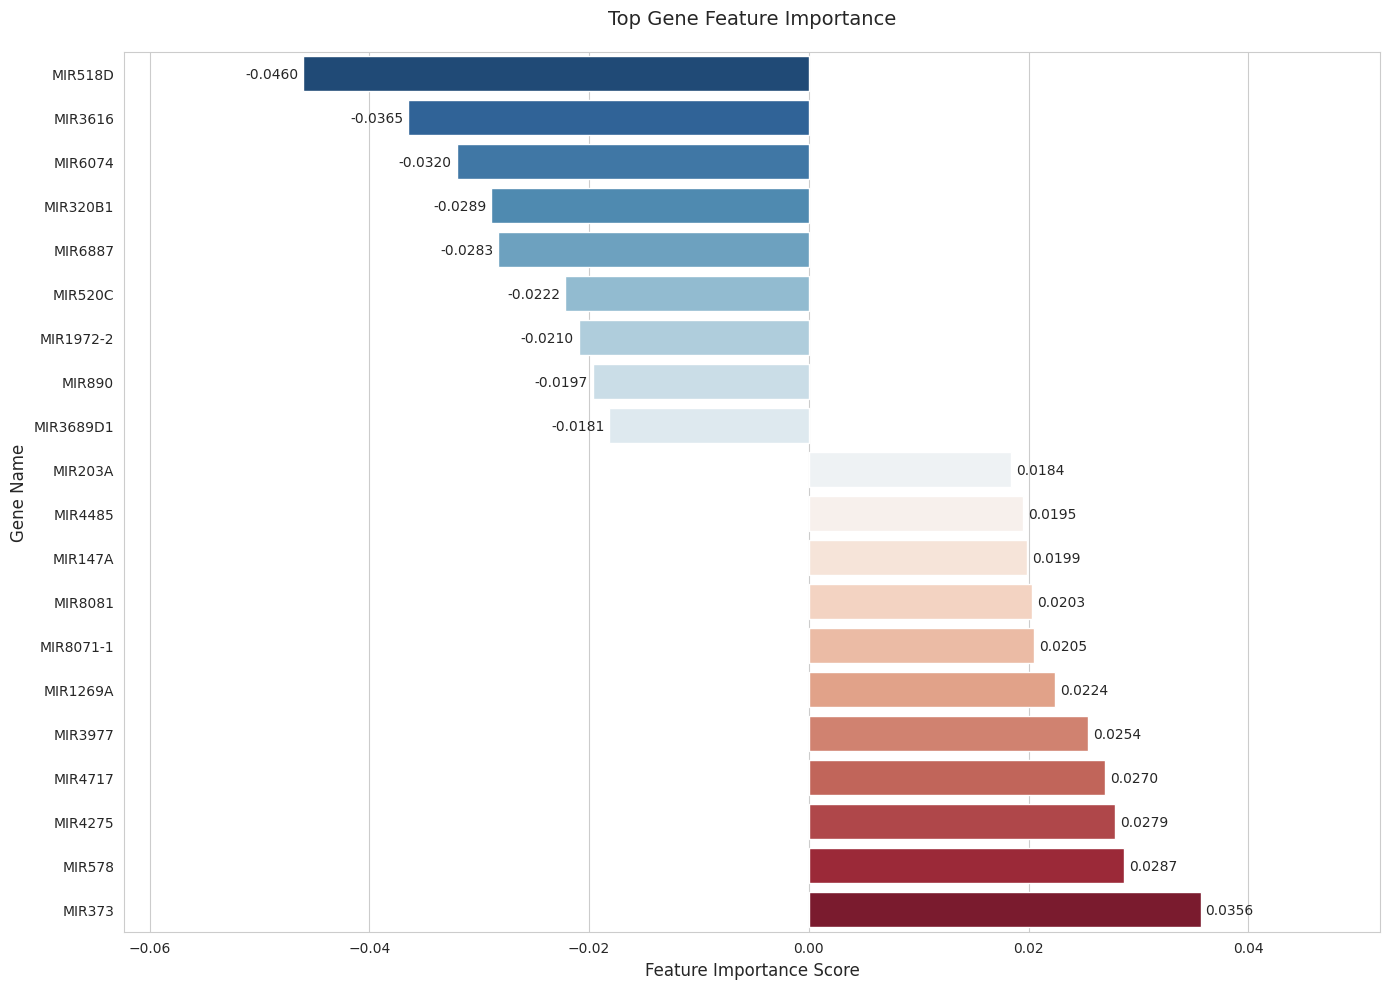

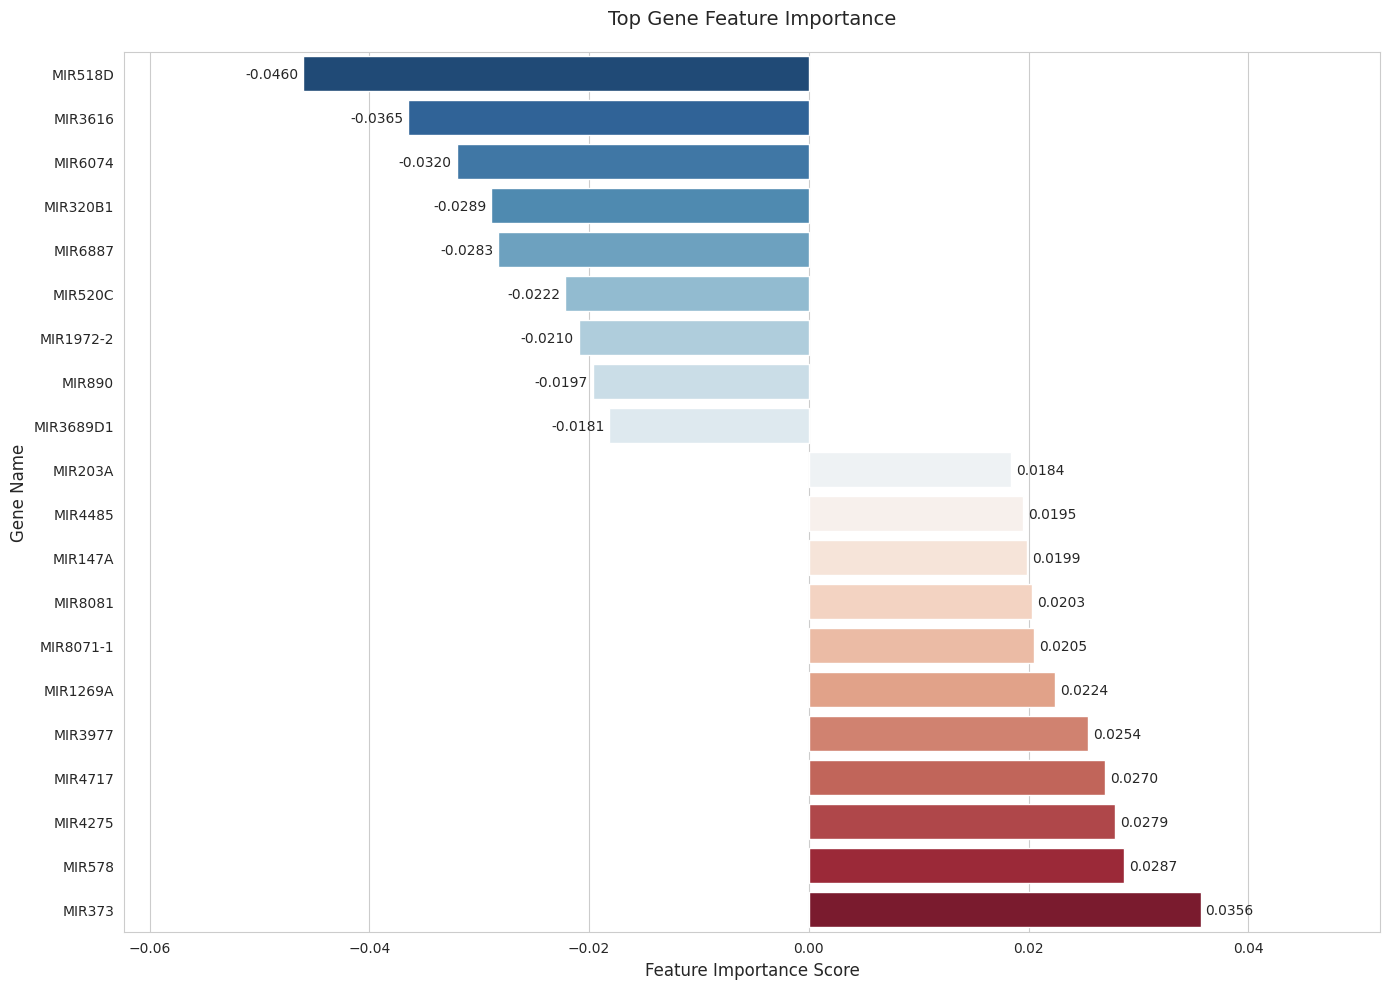

In [56]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt


def plot_top_genes(df: pl.DataFrame, n_genes=10, title=None):
    """
    Create a horizontal bar plot of the most important genes (both positive and negative).
    
    Parameters:
    df (pl.DataFrame): Polars DataFrame with gene_name and feature_importance columns
    n_genes (int): Number of top/bottom genes to display
    """
    # Sort the data by absolute importance to get most influential genes
    top_genes = (df
                 .with_columns(pl.col('feature_importance').abs().alias('abs_importance'))
                 .sort('abs_importance', descending=True)
                 .head(n_genes)
                 .sort('feature_importance')
                 .to_pandas())
    
    # Calculate figure height based on number of genes (0.4 inches per gene + padding)
    fig_height = max(8, n_genes * 0.4 + 2)
    
    # Set up the plot style with adjusted figure size
    plt.figure(figsize=(14, fig_height))
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(y='gene_name', 
                 x='feature_importance',
                 data=top_genes,
                 palette=sns.color_palette("RdBu_r", n_colors=len(top_genes)))
    
    # Customize the plot
    plt.title('Top Gene Feature Importance', pad=20, size=14)
    plt.xlabel('Feature Importance Score', size=12)
    plt.ylabel('Gene Name', size=12)
    
    # Add value labels on the bars with adjusted spacing
    max_val = top_genes['feature_importance'].abs().max()
    offset = max_val * 0.01  # Dynamic offset based on data range
    
    for i, v in enumerate(top_genes['feature_importance']):
        ax.text(v + (offset if v >= 0 else -offset), 
                i, 
                f'{v:.4f}', 
                va='center',
                ha='left' if v >= 0 else 'right',
                fontsize=10)
    
    # Adjust layout and margins
    plt.margins(x=0.2)  # Add 20% padding on x-axis
    plt.tight_layout()

    # save plot
    if title:
        plt.savefig(title)

    return plt.gcf()


plot_top_genes(midf, title="mds_disease_xgb_top_mirnas.png", n_genes=20)

In [23]:
gene_importances = {}

for g, (k, v) in zip(mrna_genes, fscores.items()):
    gene_importances[g] = v

gidf = pl.DataFrame(gene_importances)
gidf

RILPL1,RAB4B,TIGAR,DNAH3,RP11-432M8.3,RPL23A,ARL8B,DACH1,FMO2,TTC30A,PHEX,HIST1H2BF,MOGAT2,RNF44,PFN2,RMND5A,RAD23A,TUBB4A,OR2D2,SERPINB11,COX10,TLL2,MFSD3,TRABD2B,CTSA,HIST1H1T,IL32,CALB2,PRAC2,PROKR2,NUCB2,PTPN4,SERPINB12,B3GAT2,SPATA2,DPPA5,FGF23,…,FICD,COX6C,NBPF20,ZSCAN2,CFC1B,EFR3B,SSX4B,KCNA4,FOXF1,RBM18,OTOP1,FAM187B,EGF,ATPAF2,ZPBP2,RP5-1104E15.10,TBL1Y,ELOVL6,DUSP19,CABIN1,TIMP1,CNDP2,IQCJ,ELAVL1,RBAK,SLCO4C1,ARHGAP21,DDX47,POMZP3,OR8B2,EIF5B,KIF16B,CYP4F2,TENM1,BATF3,PPP6R1,OR8D4
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.000041,0.000019,-0.000004,0.000156,0.004925,-2.4303e-7,0.000001,-0.000006,0.00003,-0.000004,0.00002,-8.8417e-7,-0.000206,-9.2991e-7,0.000039,-5.7636e-7,-3.9573e-7,-0.000007,-0.000006,0.000605,0.000001,-0.000104,0.000012,-0.000143,0.000003,-0.000315,-0.000018,0.000947,-0.000361,0.00061,-3.3974e-7,0.000002,-0.001414,-0.000102,-0.000001,0.001113,-0.00022,…,1.2853e-8,4.8058e-9,-4.9266e-9,-1.3847e-8,5.3616e-9,-7.4960e-9,-1.0081e-9,5.7251e-8,-4.3663e-7,1.5082e-9,-2.8965e-7,5.7775e-9,-1.9657e-8,5.5453e-9,-3.9953e-7,4.5664e-8,2.5712e-7,-5.7071e-9,1.5848e-8,-1.0491e-9,-2.1223e-9,-4.9364e-10,-8.4526e-9,2.5473e-10,2.8829e-10,5.8431e-8,-3.3729e-10,9.7876e-10,5.2203e-8,-6.6944e-9,-1.7934e-9,-9.3957e-9,5.6726e-8,1.0177e-7,-3.8431e-7,7.7472e-10,-1.8958e-7


In [72]:
gidf30 = gidf.sort(pl.col("feature_importance").abs(), descending=True).head(200)
midf30 = midf.sort(pl.col("feature_importance").abs(), descending=True).head(200)

In [69]:
midf30

gene_name,feature_importance
str,f64
"""MIR518D""",-0.046002
"""MIR3616""",-0.036462
"""MIR373""",0.035649
"""MIR6074""",-0.032028
"""MIR320B1""",-0.02888
…,…
"""MIR4301""",-0.016551
"""MIR5689""",-0.016503
"""MIR3912""",0.016458


In [93]:
from bipartite_gnn.preprocessing import gg_interactions, get_mirna_gene_interactions, pp_interactions, get_interactions

best_30_genes = gidf30['gene_name'].to_list()

gg_interactions(best_30_genes, best_30_genes).sum()

tensor(23.)

Total interactions: 12.0
Edge between KRTAP12-2 and LCE1F (weight: 1.0)
Edge between LCE3B and LCE1F (weight: 1.0)
Edge between LCE3B and KRTAP10-10 (weight: 1.0)
Edge between LCE1A and KRTAP12-2 (weight: 1.0)
Edge between LCE1A and LCE3B (weight: 1.0)
Edge between LCE1A and LCE1F (weight: 1.0)
Edge between DUX4 and MYL1 (weight: 1.0)
Edge between IL22 and IL22RA2 (weight: 1.0)
Edge between KRTAP10-10 and LCE1F (weight: 1.0)
Edge between GAST and KIR2DL3 (weight: 1.0)
Edge between KRTAP11-1 and LCE1A (weight: 1.0)
Edge between KRTAP11-1 and LCE1F (weight: 1.0)
Removed 188 isolated nodes
Final network has 12 nodes and 12 edges


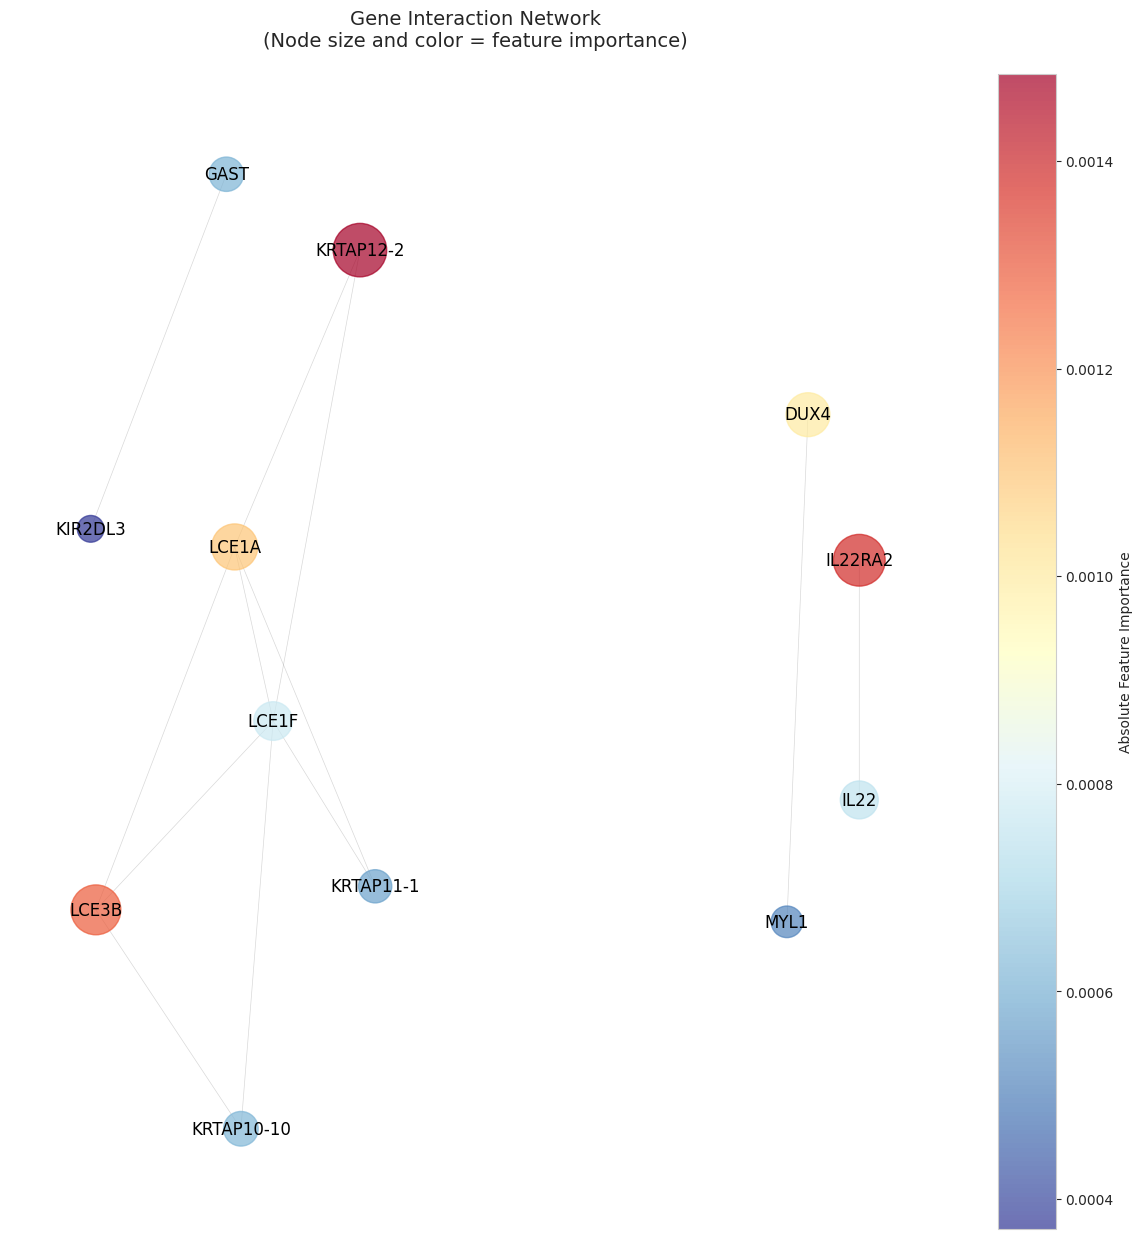

In [108]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from bipartite_gnn.preprocessing import gg_interactions

def create_gene_interaction_network(gene_scores_df: pl.DataFrame, n_top_genes: int = 200):
    """
    Create a network visualization of gene interactions for top scoring genes.
    
    Parameters:
    gene_scores_df: Polars DataFrame with gene_name and feature_importance columns
    n_top_genes: Number of top genes to include
    """
    # Get top genes by absolute importance
    top_genes = (gene_scores_df
                 .sort(pl.col("feature_importance").abs(), descending=True)
                 .head(n_top_genes))
    
    # Get gene names and create interaction matrix
    gene_names = top_genes['gene_name'].to_list()
    A = gg_interactions(gene_names, gene_names) - np.eye(len(gene_names))
    
    # Create network graph
    G = nx.Graph()
    
    # Add nodes with their importance scores
    scores_dict = dict(zip(top_genes['gene_name'].to_list(),
                          abs(top_genes['feature_importance']).to_list()))
    
    # Add nodes
    for gene in gene_names:
        G.add_node(gene, importance=scores_dict[gene])
    
    print(f"Total interactions: {A[A > 0].sum()}")
    
    # Add edges
    for i in range(len(gene_names)):
        for j in range(len(gene_names)):
            if A[i, j] > 0:
                print(f"Edge between {gene_names[i]} and {gene_names[j]} (weight: {A[i, j]})")
                G.add_edge(gene_names[i], gene_names[j])
    
    # Remove isolated nodes
    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)
    print(f"Removed {len(isolated_nodes)} isolated nodes")
    print(f"Final network has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
    
    # Create plot
    plt.figure(figsize=(15, 15))
    
    # Calculate layout with adjusted parameters for better spacing
    pos = nx.spring_layout(G, k=2, iterations=100, seed=42)
    
    # Get node colors and sizes with adjusted scaling
    node_sizes = [1 * 10**6 * G.nodes[node]['importance'] for node in G.nodes()]
    node_colors = [G.nodes[node]['importance'] for node in G.nodes()]
    
    # Draw the network
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=0.5)
    nodes = nx.draw_networkx_nodes(G, pos,
                                 node_size=node_sizes,
                                 node_color=node_colors,
                                 cmap=plt.cm.RdYlBu_r,
                                 alpha=0.7)
    
    # Add labels with adjusted font size based on network size
    font_size = 12# max(6, min(8, 12 - len(G.nodes)))  # Adaptive font sizing
    nx.draw_networkx_labels(G, pos, font_size=font_size)
    
    # Add colorbar
    plt.colorbar(nodes, label='Absolute Feature Importance')
    
    # Customize plot
    plt.title('Gene Interaction Network\n(Node size and color = feature importance)',
             pad=20, size=14)
    plt.axis('off')
    
    return G, plt.gcf()

G, fig = create_gene_interaction_network(gidf30, n_top_genes=200)
plt.show()  # This should now display the plot correctly
# plt.savefig("feature_importances/mds_gene_graph.png")

In [68]:
mirna_mrna_interactions = pl.read_csv(
    'MDS_data/mirna-mrna-interactions.csv',
    separator=','
)
mirna_mrna_interactions.with_columns(
    pl.col("mature_mirna_id").str.replace("hsa-", ""),
)

,mature_mirna_id,target_symbol
i64,str,str
1,"""hsa-let-7a-5p""","""NF2"""
3,"""hsa-let-7a-5p""","""KRAS"""
11,"""hsa-let-7a-5p""","""NRAS"""
29,"""hsa-let-7a-5p""","""TRIM71"""
31,"""hsa-let-7a-5p""","""HMGA2"""
…,…,…
621958,"""hsa-miR-99b-5p…","""DCP1A"""
622216,"""hsa-miR-99b-5p…","""H2BC8"""
623202,"""hsa-miR-99b-5p…","""TUBGCP5"""


In [94]:
mlp_eval(X, y, reg_type=None, n_trials=15)

Trial 0 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.66666669 1.         0.66666669 1.         0.66666669]
[0.66666667 1.         0.66666667 1.         0.66666667]
[0.66666667 1.         0.66666667 1.         0.66666667]
{'acc': 0.800000011920929, 'f1_macro': 0.7999999999999999, 'f1_weighted': 0.7999999999999999, 'acc_std': 0.16329930645214746, 'f1_macro_std': 0.16329931618554525, 'f1_weighted_std': 0.16329931618554525}
Trial 1 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.66666669 1.         0.66666669 1.         0.66666669]
[0.66666667 1.         0.66666667 1.         0.66666667]
[0.66666667 1.         0.66666667 1.         0.66666667]
Trial 2 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.66666669 1.         0.66666669 1.         0.66666669]
[0.66666667 1.         0.66666667 1.         0.66666667]
[0.66666667 1.         0.66666667 1.         0.66666667]
Trial 3 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.66666669 

{'acc': 0.9, 'f1_macro': 0.7856410256410257, 'f1_weighted': 0.8851282051282052, 'acc_std': 0.09354143466934853, 'f1_macro_std': 0.20390403951541392, 'f1_weighted_std': 0.10002169389933914}

| MLP no regularization |  0.90 +- 0.09 |  0.79 +- 0.20 |  0.89 +- 0.10 |

In [95]:
mlp_eval(X, y, reg_type='l1', n_trials=13)

Trial 0 / 13
Eval 1 / 5
torch.Size([20, 572])
torch.Size([3, 572])
torch.Size([3, 572])
Eval 2 / 5
torch.Size([21, 572])
torch.Size([2, 572])
torch.Size([3, 572])
Eval 3 / 5
torch.Size([21, 572])
torch.Size([2, 572])
torch.Size([3, 572])
Eval 4 / 5
torch.Size([21, 572])
torch.Size([2, 572])
torch.Size([3, 572])
Eval 5 / 5
torch.Size([21, 572])
torch.Size([2, 572])
torch.Size([3, 572])
[0.66666669 1.         0.66666669 0.         1.        ]
[0.66666667 1.         0.66666667 0.         1.        ]
[0.66666667 1.         0.66666667 0.         1.        ]
{'acc': 0.6666666746139527, 'f1_macro': 0.6666666666666666, 'f1_weighted': 0.6666666666666666, 'acc_std': 0.3651483716701108, 'f1_macro_std': 0.36514837167011077, 'f1_weighted_std': 0.36514837167011077}
Trial 1 / 13
Eval 1 / 5
torch.Size([20, 2527])
torch.Size([3, 2527])
torch.Size([3, 2527])
Eval 2 / 5
torch.Size([21, 2527])
torch.Size([2, 2527])
torch.Size([3, 2527])
Eval 3 / 5
torch.Size([21, 2527])
torch.Size([2, 2527])
torch.Size([3

In [8]:
mlp_eval(X, y, reg_type='inner_mat', n_trials=13)

Trial 0 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.83333331 0.66666669 0.66666669 0.60000002 0.60000002]
[0.82857143 0.625      0.66666667 0.58333333 0.58333333]
[0.82857143 0.625      0.66666667 0.56666667 0.6       ]
{'acc': 0.6733333468437195, 'f1_macro': 0.6573809523809523, 'f1_weighted': 0.6573809523809524, 'acc_std': 0.08537497357327423, 'f1_macro_std': 0.09100223016878, 'f1_weighted_std': 0.09161068172873033}
Trial 1 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
Pruning trial after 5 evals, cause 0.4714285714285714 < 0.6573809523809524
[0.66666669 0.5        0.5        0.40000001 0.80000001]
[0.66666667 0.33333333 0.48571429 0.4        0.76190476]
[0.66666667 0.33333333 0.48571429 0.4        0.78095238]
Trial 2 / 15
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5
[0.83333331 0.5        0.66666669 0.60000002 0.80000001]
[0.82857143 0.33333333 0.66666667 0.58333333 0.76190476]
[0.82857143 0.33333333 0.66666667 0.56666667 0.78095238]
Trial 3

In [29]:
te_counts

TE,V1884,N58,V630,N60,V1297,NV1428,N82,V940,V2092,V624,V777,V553,V1441,V1921,V538,V1857,V456,NV912,V2089,V1823,V2241,N54,V655,V2110,V839,V125,N83,V637,V712,NV911,V2133,V1742,V1591,V108,V1874,V221,V148,N70,N87,V574,V359,V1337,V883,V1592,V1422,V1708,V1505,V18,V1788,V1776,N84,V1800,V716,N86,V888,V1321,V1279,V1528,V344,N85,V1699,V1456,V1394,V714,V67,V1090,V1860,V406,V1834,V1048,V806,V513,V1565,V1920
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALU""",13599.0,7019.28,6877.89,9306.07,7721.05,8097.26,7271.96,6593.15,4629.16,6690.64,6061.99,13410.6,6021.26,6612.61,9357.52,6009.74,8183.79,6439.34,10564.3,4946.98,6080.92,8622.08,7078.72,5222.05,7881.51,8590.44,9375.79,7523.42,6516.82,6199.62,4091.96,9511.53,6148.82,8986.45,6513.3,7065.91,7903.22,8494.2,7966.3,8245.11,8871.46,7430.7,6081.12,7800.57,8908.25,9530.9,6618.57,6264.46,7317.08,6959.7,8072.73,8582.4,11432.6,7318.48,9143.6,9322.82,8150.22,5652.82,8698.03,7290.05,9072.45,5909.45,5579.7,6303.3,8766.84,8221.49,4741.42,12638.6,9892.05,6385.99,7599.44,7370.1,7059.21,9787.8
"""AluJb""",44735.8,26406.7,24896.5,35332.8,24279.6,25259.1,28840.1,23699.4,18683.8,24140.9,22834.9,59175.4,21895.8,24058.9,30827.4,23024.3,28090.8,22857.0,25346.5,17890.9,23690.8,26817.6,26045.3,22804.4,27292.4,34593.1,34302.9,21814.8,23824.4,21670.0,18005.5,35568.6,24160.7,27678.3,25387.7,26280.0,32247.8,29455.4,27669.4,30616.8,33447.7,24996.5,22348.0,28009.3,30466.0,29308.3,21067.6,21639.5,29796.4,23285.4,29860.5,33905.1,40157.1,24799.0,34480.6,33224.7,25811.1,18688.7,26701.3,27695.8,38196.9,21118.1,19816.4,21455.6,22323.5,25617.0,20686.7,41178.3,40239.7,22606.9,28709.9,25891.1,27218.6,38261.4
"""AluJo""",4257.09,4019.45,2666.19,4933.68,2681.86,2740.94,3429.15,3666.81,2532.95,3233.89,2941.52,7165.52,2868.0,2720.84,3510.82,2825.34,3125.83,3364.17,101.421,2786.46,3107.17,2462.54,3315.78,3165.13,3839.13,4826.98,3989.25,8.64467,3006.96,3348.82,1896.2,5215.14,3312.06,2273.46,3269.16,3609.03,4382.27,3074.27,3584.89,4266.58,4705.06,3504.48,3394.73,3451.88,2569.22,2902.06,2930.32,2626.65,3817.81,2831.86,4071.69,4512.76,3849.75,3297.0,4724.76,4027.51,3258.88,2600.59,3709.33,3677.09,4838.48,2426.03,2744.18,2624.93,74.3837,2730.77,2571.26,5306.78,4179.26,3670.61,4184.29,3155.55,3744.24,5137.53
"""AluJr""",1806.28,1220.17,1063.58,1550.93,1046.95,1032.61,1232.72,1163.09,881.944,1000.22,1003.92,2560.71,967.78,1028.65,1272.53,1195.26,1174.99,1143.35,936.128,736.021,863.661,1099.74,1299.6,930.15,1087.77,1348.67,1318.97,1019.45,1130.95,935.308,1091.74,1759.8,939.429,1141.14,979.688,1158.42,1347.83,1274.11,1316.59,978.277,1687.27,1002.38,1015.1,1135.73,1265.34,1213.18,802.787,842.567,1365.8,943.936,1108.86,1278.44,1840.33,992.346,1567.68,1417.94,1085.42,810.193,1286.5,1153.25,1818.89,857.841,688.697,886.429,964.59,1003.94,689.1,1945.98,1870.29,1048.49,1238.01,1206.32,1180.33,1694.92
"""AluJr4""",10841.0,6707.35,6414.47,8444.05,5862.15,6608.18,7250.13,6350.26,4784.68,6364.48,5932.29,13894.9,6099.33,6065.9,7202.02,5005.56,6738.61,5878.63,7226.66,5106.92,5902.87,6563.21,6111.24,5670.5,6929.24,8564.76,8638.74,5240.83,5925.11,5709.1,3681.26,8767.59,6496.37,6722.98,7081.09,6557.64,7512.87,7826.48,7409.45,7026.02,8421.84,6421.22,5684.14,7221.28,7237.18,7221.67,6093.45,6530.15,8028.43,5759.8,7839.1,8615.35,10055.5,6227.68,8494.22,7898.21,6450.93,5157.1,7028.46,7137.76,9584.53,5299.94,5702.57,5720.99,5960.01,6767.55,5243.51,10187.5,9185.61,6158.79,7286.93,6622.88,7417.67,9023.09
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""X5A_LINE""",3.0,4.0,4.0,9.0,4.0,10.0,1.0,14.0,6.0,4.0,8.0,11.0,15.0,12.0,22.0,7.0,16.0,3.0,5.0,10.0,14.0,9.0,4.0,1.0,16.0,8.0,0.0,1.0,5.0,1.0,3.0,6.0,11.0,21.0,

In [91]:
val, test = mogonet_eval(
    input_omics={
        "mrna": mrna,
        # "mirna": mirna,
        # "circrna": circrna,
        # "te_counts": te_counts,
    },
    n_input_features={
        "mrna": 1000,
        # "mirna": 1000,
        # "circrna": 60,
        # "te_counts": 300,
    },
    y=y,
    params={
        "encoder_hidden_channels": {
            "mrna": 300,
            # "circrna": 50,
            # "mirna": 150,
            # "te_counts": 75,
        },
        "encoder_type": "gcn",
        "num_classes": 2,
        "graph_style": "threshold",
        "avg_degree": 15,
        # "graph_style": "knn",
        # "knn": 15,
        "dropout": 0.0,
        "epochs": 400,
        "log_interval": 50,
        "save_best_model": False,
        "integrator_type": "vcdn",
        "integration_dim": 2,
    }
)

dict_keys(['mrna'])
Fold 1 / 5
Building graph for mrna
0.75 tensor(58.5946)
0.875 tensor(22.7838)
0.9375 tensor(1.7838)
0.90625 tensor(10.0541)
0.890625 tensor(16.6757)
0.8984375 tensor(13.2432)
0.89453125 tensor(14.8649)
Isolated samples = 15, avg degree = 14.86486530303955
Epoch: 050:
Train Loss: 0.4031, Train Acc: 0.8000, Train F1 Macro: 0.7980, Train F1 Weighted: 0.8000
Val Loss: 0.2493, Val Acc: 1.0000, Val F1 Macro: 1.0000, Val F1 Weighted: 1.0000
Test Loss: 0.5027, Test Acc: 0.6667, Test F1 Macro: 0.6667, Test F1 Weighted: 0.6667
##################################################
Epoch: 100:
Train Loss: 0.3316, Train Acc: 0.8500, Train F1 Macro: 0.8400, Train F1 Weighted: 0.8440
Val Loss: 0.2688, Val Acc: 0.6667, Val F1 Macro: 0.6667, Val F1 Weighted: 0.6667
Test Loss: 0.4153, Test Acc: 1.0000, Test F1 Macro: 1.0000, Test F1 Weighted: 1.0000
##################################################
Epoch: 150:
Train Loss: 0.2798, Train Acc: 0.8500, Train F1 Macro: 0.8496, Train F1 Weig

In [72]:
val, test

NameError: name 'val' is not defined

In [93]:
print("MOGONET GCN (mrna only) results:")
print(f"| MOGONET GCN (mrna only) val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| MOGONET GCN (mrna only) test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

MOGONET GCN (mrna only) results:
| MOGONET GCN (mrna only) val | 0.83 +/- 0.24 | 0.80 +/- 0.30 | 0.80 +/- 0.30 |
| MOGONET GCN (mrna only) test | 0.73 +/- 0.15 | 0.73 +/- 0.15 | 0.73 +/- 0.15 |


In [89]:
print("MOGONET GAT (mrna only) results:")
print(f"| MOGONET GAT (mrna only) val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| MOGONET GAT (mrna only) test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

MOGONET GAT (mrna only) results:
| MOGONET GAT (mrna only) val | 1.00 +/- 0.00 | 1.00 +/- 0.00 | 1.00 +/- 0.00 |
| MOGONET GAT (mrna only) test | 0.53 +/- 0.38 | 0.52 +/- 0.39 | 0.53 +/- 0.38 |


# DISEASE

## mrna only
| Model | Accuracy | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.91 +/- 0.08 | 0.76 +/- 0.21 | 0.89 +/- 0.10 |
| LIN SVM | 0.85 +/- 0.11 | 0.79 +/- 0.11 | 0.86 +/- 0.09 |
| XGBoost | 0.93 +/- 0.06 | 0.89 +/- 0.09 | 0.94 +/- 0.06 |
| MLP no regularization | 0.90 +/- 0.09 | 0.79 +/- 0.20 | 0.89 +/- 0.10 |
| MLP l1 regularization | 0.90 +/- 0.09 | 0.79 +/- 0.20 | 0.89 +/- 0.10 |
| MLP inner mat | 0.90 +/- 0.09 | 0.79 +/- 0.20 | 0.89 +/- 0.10 |
| MOGONET GCN (mrna only) | 0.82 +/- 0.12 | 0.76 +/- 0.15 | 0.83 +/- 0.10 |
| MOGONET GAT (mrna only) | 0.93 +/- 0.07 | 0.89 +/- 0.10 | 0.93 +/- 0.07 |
| Bipartite GNN (mrna only) | 0.94 +/- 0.08 | 0.92 +/- 0.12 | 0.95 +/- 0.07 |

## all



# RISK

## mrna only
| KNN | 0.89 +/- 0.11 | 0.75 +/- 0.26 | 0.88 +/- 0.13 |
| LIN SVM | 0.88 +/- 0.11 | 0.84 +/- 0.12 | 0.89 +/- 0.10 |
| XGBoost | 0.93 +/- 0.04 | 0.89 +/- 0.07 | 0.93 +/- 0.04 |
| MLP no regularization |  0.90 +- 0.09 |  0.79 +- 0.20 |  0.89 +- 0.10 |
| MLP regularization : l1 | 0.71 +/- 0.17 | 0.67 +/- 0.21 | 0.69 +/- 0.19 |
| MLP regularization : inner_mat | 0.71 +/- 0.09 | 0.70 +/- 0.10 | 0.70 +/- 0.10 |
| MOGONET GCN (mrna only) test | 0.64 +/- 0.15 | 0.61 +/- 0.19 | 0.60 +/- 0.21 |
| MOGONET GAT (mrna only) test | 0.71 +/- 0.10 | 0.71 +/- 0.10 | 0.71 +/- 0.10 |

## all
| KNN | 0.70 +/- 0.15 | 0.65 +/- 0.20 | 0.66 +/- 0.19 |
| LIN SVM | 0.72 +/- 0.12 | 0.70 +/- 0.13 | 0.71 +/- 0.13 |
| XGBoost | 0.66 +/- 0.07 | 0.63 +/- 0.07 | 0.64 +/- 0.07 |
| MLP regularization : None | 0.71 +/- 0.09 | 0.69 +/- 0.09 | 0.69 +/- 0.10 |
| MLP regularization : l1 | 0.71 +/- 0.09 | 0.70 +/- 0.10 | 0.70 +/- 0.10 |
| MLP regularization : inner_mat | 0.71 +/- 0.09 | 0.70 +/- 0.10 | 0.70 +/- 0.10 |
| MOGONET GAT (mrna only) test | 0.71 +/- 0.10 | 0.71 +/- 0.10 | 0.71 +/- 0.10 |


# MUTATION

| KNN | 0.79 +/- 0.24 | 0.78 +/- 0.24 | 0.78 +/- 0.24 |
| LIN SVM | 0.89 +/- 0.09 | 0.89 +/- 0.09 | 0.89 +/- 0.09 |
| XGBoost | 0.92 +/- 0.10 | 0.91 +/- 0.11 | 0.92 +/- 0.10 |
| MLP regularization : None | 0.80 +/- 0.16 | 0.80 +/- 0.16 | 0.80 +/- 0.16 |
